In [38]:
import os
import sys

import numpy as np
import pandas as pd
import warnings

warnings.filterwarnings("ignore")
sys.path.append(os.path.abspath(os.path.join("modelling", '../..')))

from utility import plot

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from xgboost import XGBClassifier # Added XGBClassifier
from sklearn.ensemble import RandomForestClassifier # Added RandomForestClassifier

from sklearn.preprocessing import StandardScaler

In [28]:
SEED = 42
PLOT_DPI = 100

TRAIN_DATA_FILE = "../../datasets/Skoltech_Anomaly_Benchmark/preprocessed_skab_dataset_set2_train.csv"
TEST_DATA_FILE = "../../datasets/Skoltech_Anomaly_Benchmark/preprocessed_skab_dataset_set2_test.csv"

In [29]:
dataframe_train = pd.read_csv(TRAIN_DATA_FILE)
dataframe_train

,Accelerometer1RMS,Accelerometer2RMS,Current,Pressure,Temperature,Thermocouple,Voltage,Volume Flow RateRMS,Electrical_Resistence,Flow_Resistance,...,Engine_Temperature_pu_Power,Efficiency_Temperature_Difference_Ratio,AccelerometerRMS_Fluctuation,Temperature_Fluctuation,Thermocouple_Fluctuation,Volume Flow RateRMS_Fluctuation,Hydraulic_Power_Fluctuation,Electrical_Power_Fluctuation,description,anomaly
0,0.219595,0.267058,2.972050,1.074847,88.9166,28.9319,227.339,127.0000,76.492320,0.008463,...,0.154822,0.006604,0.000495,0.059292,0.002836,0.052960,13.772706,101.000067,No Anomaly,0.0
1,0.028225,0.042124,1.432100,1.401284,68.6462,24.7640,245.677,32.9805,171.550171,0.042488,...,0.229541,0.005869,0.000024,0.086108,0.003364,0.161704,5.272073,27.131990,No Anomaly,0.0
2,0.214053,0.259569,2.228980,1.730701,88.2787,29.6790,227.822,127.0000,102.209082,0.013628,...,0.204520,0.014483,0.000405,0.238396,0.004220,0.210480,47.116885,38.577988,No Anomaly,0.0
3,0.255422,0.294430,2.998710,1.074847,86.2073,28.8126,232.379,126.0000,77.492989,0.008531,...,0.145544,0.006640,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,No Anomaly,0.0
4,0.081667,0.129274,1.561180,0.733489,87.2407,22.1358,234.136,77.0000,149.973738,0.009526,...,0.280788,0.004654,0.000065,0.076840,0.004868,0.389792,7.142787,32.665876,No Anomaly,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34436,0.028173,0.041713,0.850848,0.745430,70.8238,25.2266,233.644,32.9921,274.601339,0.022594,...,0.419135,0.005320,0.000031,0.033940,0.004332,0.356680,6.444470,34.806232,No Anomaly,0.0
34437,0.080816,0.127709,1.614570,1.061416,87.1087,22.1432,230.259,76.9806,142.613204,0.013788,...,0.275657,0.006633,0.000120,0.088008,0.002244,0.425900,23.359892,73.578876,No Anomaly,0.0
34438,0.027668,0.041262,1.407610,1.401284,69.1150,24.8253,238.183,32.0000,169.210932,0.043790,...,0.242527,0.005921,0.000027,0.118400,0.004124,0.357284,10.415008,42.637613,No Anomaly,0.0
34439,0.209388,0.262548,2.756810,1.074847,88.4803,29.5671,235.927,127.6810,85.579710,0.008418,...,0.160045,0.007023,0.000280,0.041504,0.002468,0.265360,53.116416,18.142574,No Anomaly,0.0


In [30]:
dataframe_test = pd.read_csv(TEST_DATA_FILE)
dataframe_test

,Accelerometer1RMS,Accelerometer2RMS,Current,Pressure,Temperature,Thermocouple,Voltage,Volume Flow RateRMS,Electrical_Resistence,Flow_Resistance,...,Engine_Temperature_pu_Power,Efficiency_Temperature_Difference_Ratio,AccelerometerRMS_Fluctuation,Temperature_Fluctuation,Thermocouple_Fluctuation,Volume Flow RateRMS_Fluctuation,Hydraulic_Power_Fluctuation,Electrical_Power_Fluctuation,description,anomaly
0,0.210323,0.262893,2.658640,1.074847,88.6217,29.3147,230.091,126.6770,86.544624,0.008485,...,0.170436,0.007359,0.000450,0.115096,0.005824,0.285160,8.584219,126.989244,No Anomaly,0.0
1,0.028297,0.042536,0.814120,0.745430,68.0318,24.2354,232.174,32.0000,285.184002,0.023295,...,0.423439,0.005650,0.000042,0.111232,0.004348,0.038412,16.180027,34.680405,No Anomaly,0.0
2,0.028185,0.041387,0.810610,1.073357,68.8750,24.7075,208.422,32.0000,257.117479,0.033542,...,0.479609,0.009025,0.000026,0.029276,0.006124,0.199256,12.170266,28.633766,No Anomaly,0.0
3,0.027955,0.042217,1.125930,1.073357,68.9973,24.7679,235.556,27.0000,209.210164,0.039754,...,0.306061,0.004844,0.000024,0.018756,0.002284,0.310260,8.450375,7.272027,Inlet Valve Malfunction,12.0
4,0.211749,0.272061,2.654510,1.402774,90.2739,27.8473,225.678,123.6680,85.016820,0.011343,...,0.177284,0.009096,0.000340,0.075920,0.004140,0.320000,21.923342,83.523038,No Anomaly,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7376,0.027119,0.039793,1.145980,1.073357,69.6155,24.9792,230.324,31.0000,200.984310,0.034624,...,0.310292,0.005538,0.000017,0.051492,0.003720,0.312968,18.169994,43.781339,Inlet Valve Malfunction,12.0
7377,0.209236,0.261347,2.532400,1.074847,88.9830,29.1743,222.902,126.0000,88.020060,0.008531,...,0.185456,0.007866,0.000314,0.162908,0.003280,0.386440,39.007200,33.850955,No Anomaly,0.0
7378,0.027496,0.039704,0.618982,1.073357,68.3109,24.4975,229.008,32.0317,369.975217,0.033509,...,0.566947,0.010855,0.000030,0.093068,0.004288,0.376272,7.216541,31.761236,No Anomaly,0.0
7379,0.243079,0.287370,2.320710,1.402774,85.5501,29.4859,250.139,127.3840,107.785548,0.011012,...,0.173380,0.010766,0.001260,0.094164,0.005896,0.459960,39.482278,107.722079,No Anomaly,0.0


In [31]:
X_train = dataframe_train.drop(columns=["anomaly", "description"]).values
y_train = dataframe_train["anomaly"].values.ravel()

X_test = dataframe_test.drop(columns=["anomaly", "description"]).values
y_test = dataframe_test["anomaly"].values.ravel()

In [32]:
combined = zip(dataframe_train.anomaly.values, dataframe_train.description.values)
sorted_pairs = sorted(combined, key=lambda pair: pair[0])

anomaly_ids = dict()
for i in sorted_pairs:
    anomaly_ids[i[0]] = i[1]

anomaly_names = [val for key, val in anomaly_ids.items()]

### Logistic Regression

In [42]:
# 2. Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression(solver='lbfgs', multi_class='ovr', C=5) # 'lbfgs' is a good general-purpose solver
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.8717


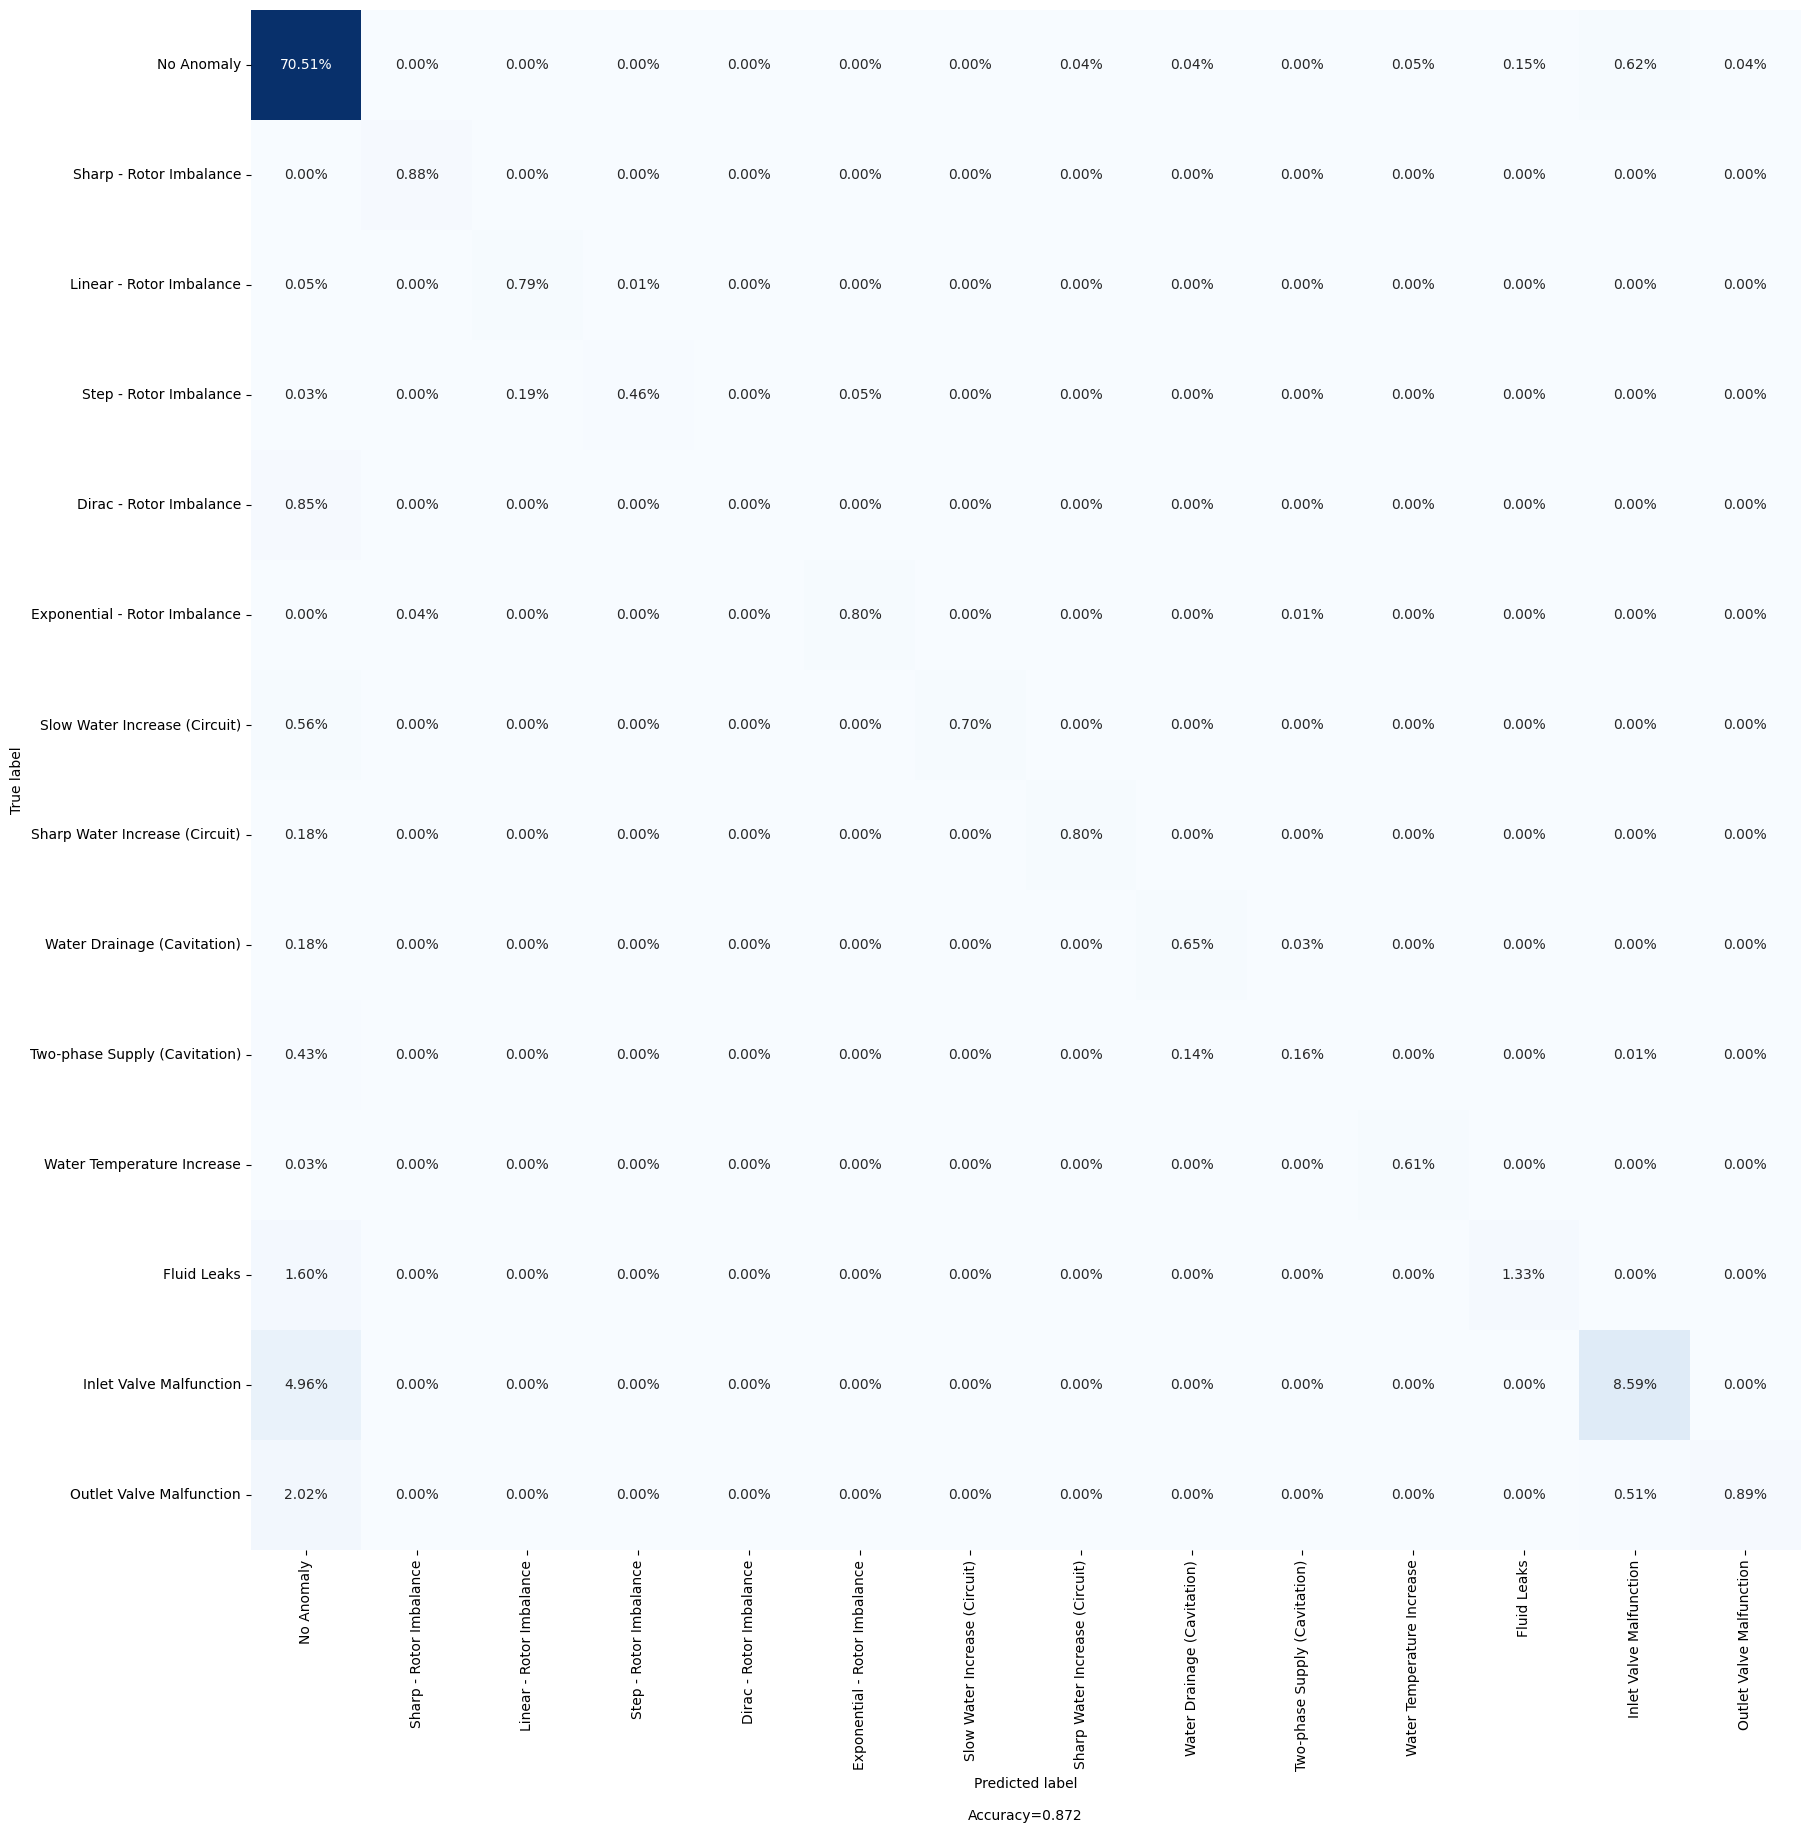

In [43]:
plot.make_confusion_matrix(
    confusion_matrix(y_test, y_pred),
    categories=anomaly_names,
    count=False,
    cbar=False,
    figsize=(20, 20)
)

### SVM

In [35]:
# 2. Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 3. Instantiate and Train SVM
svm_model = SVC(kernel='rbf', C=1.0, gamma='scale') # Example with RBF kernel
svm_model.fit(X_train_scaled, y_train)

# 4. Make Predictions and Evaluate
y_pred = svm_model.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.4f}")

Model Accuracy: 0.8557


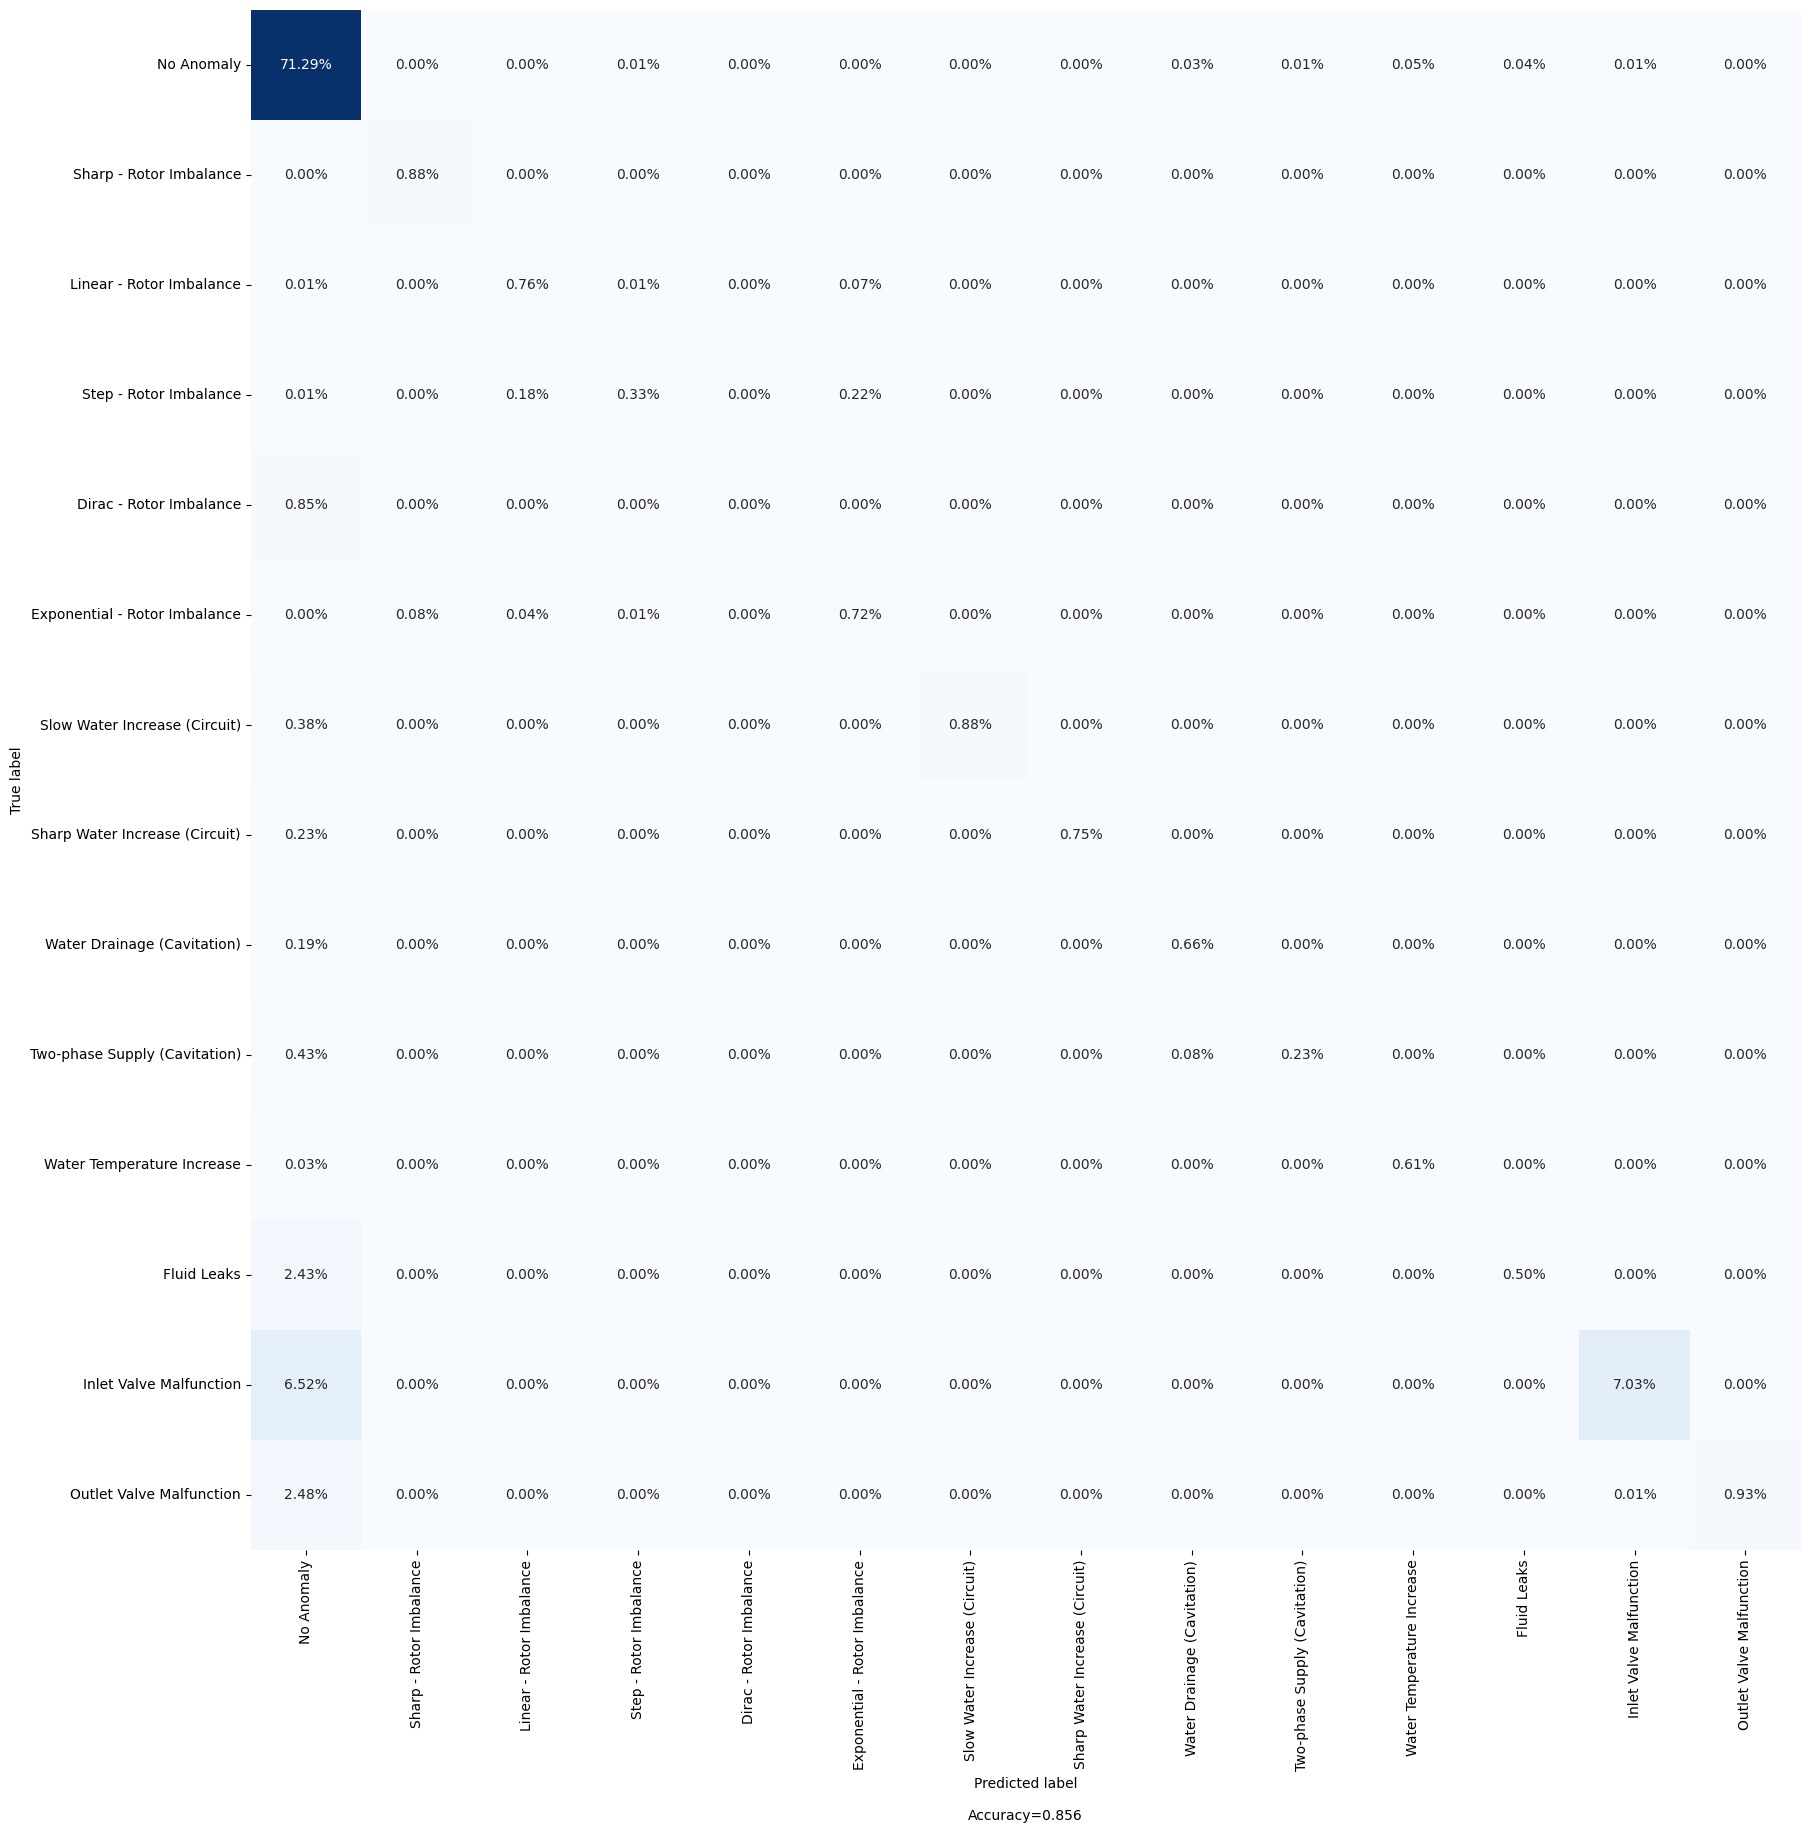

In [36]:
plot.make_confusion_matrix(
    confusion_matrix(y_test, y_pred),
    categories=anomaly_names,
    count=False,
    cbar=False,
    figsize=(20, 20)
)

### Random Forest Classifier

In [44]:
# 2. Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = RandomForestClassifier(n_estimators=100, random_state=SEED)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.4f}")

Model Accuracy: 0.9623


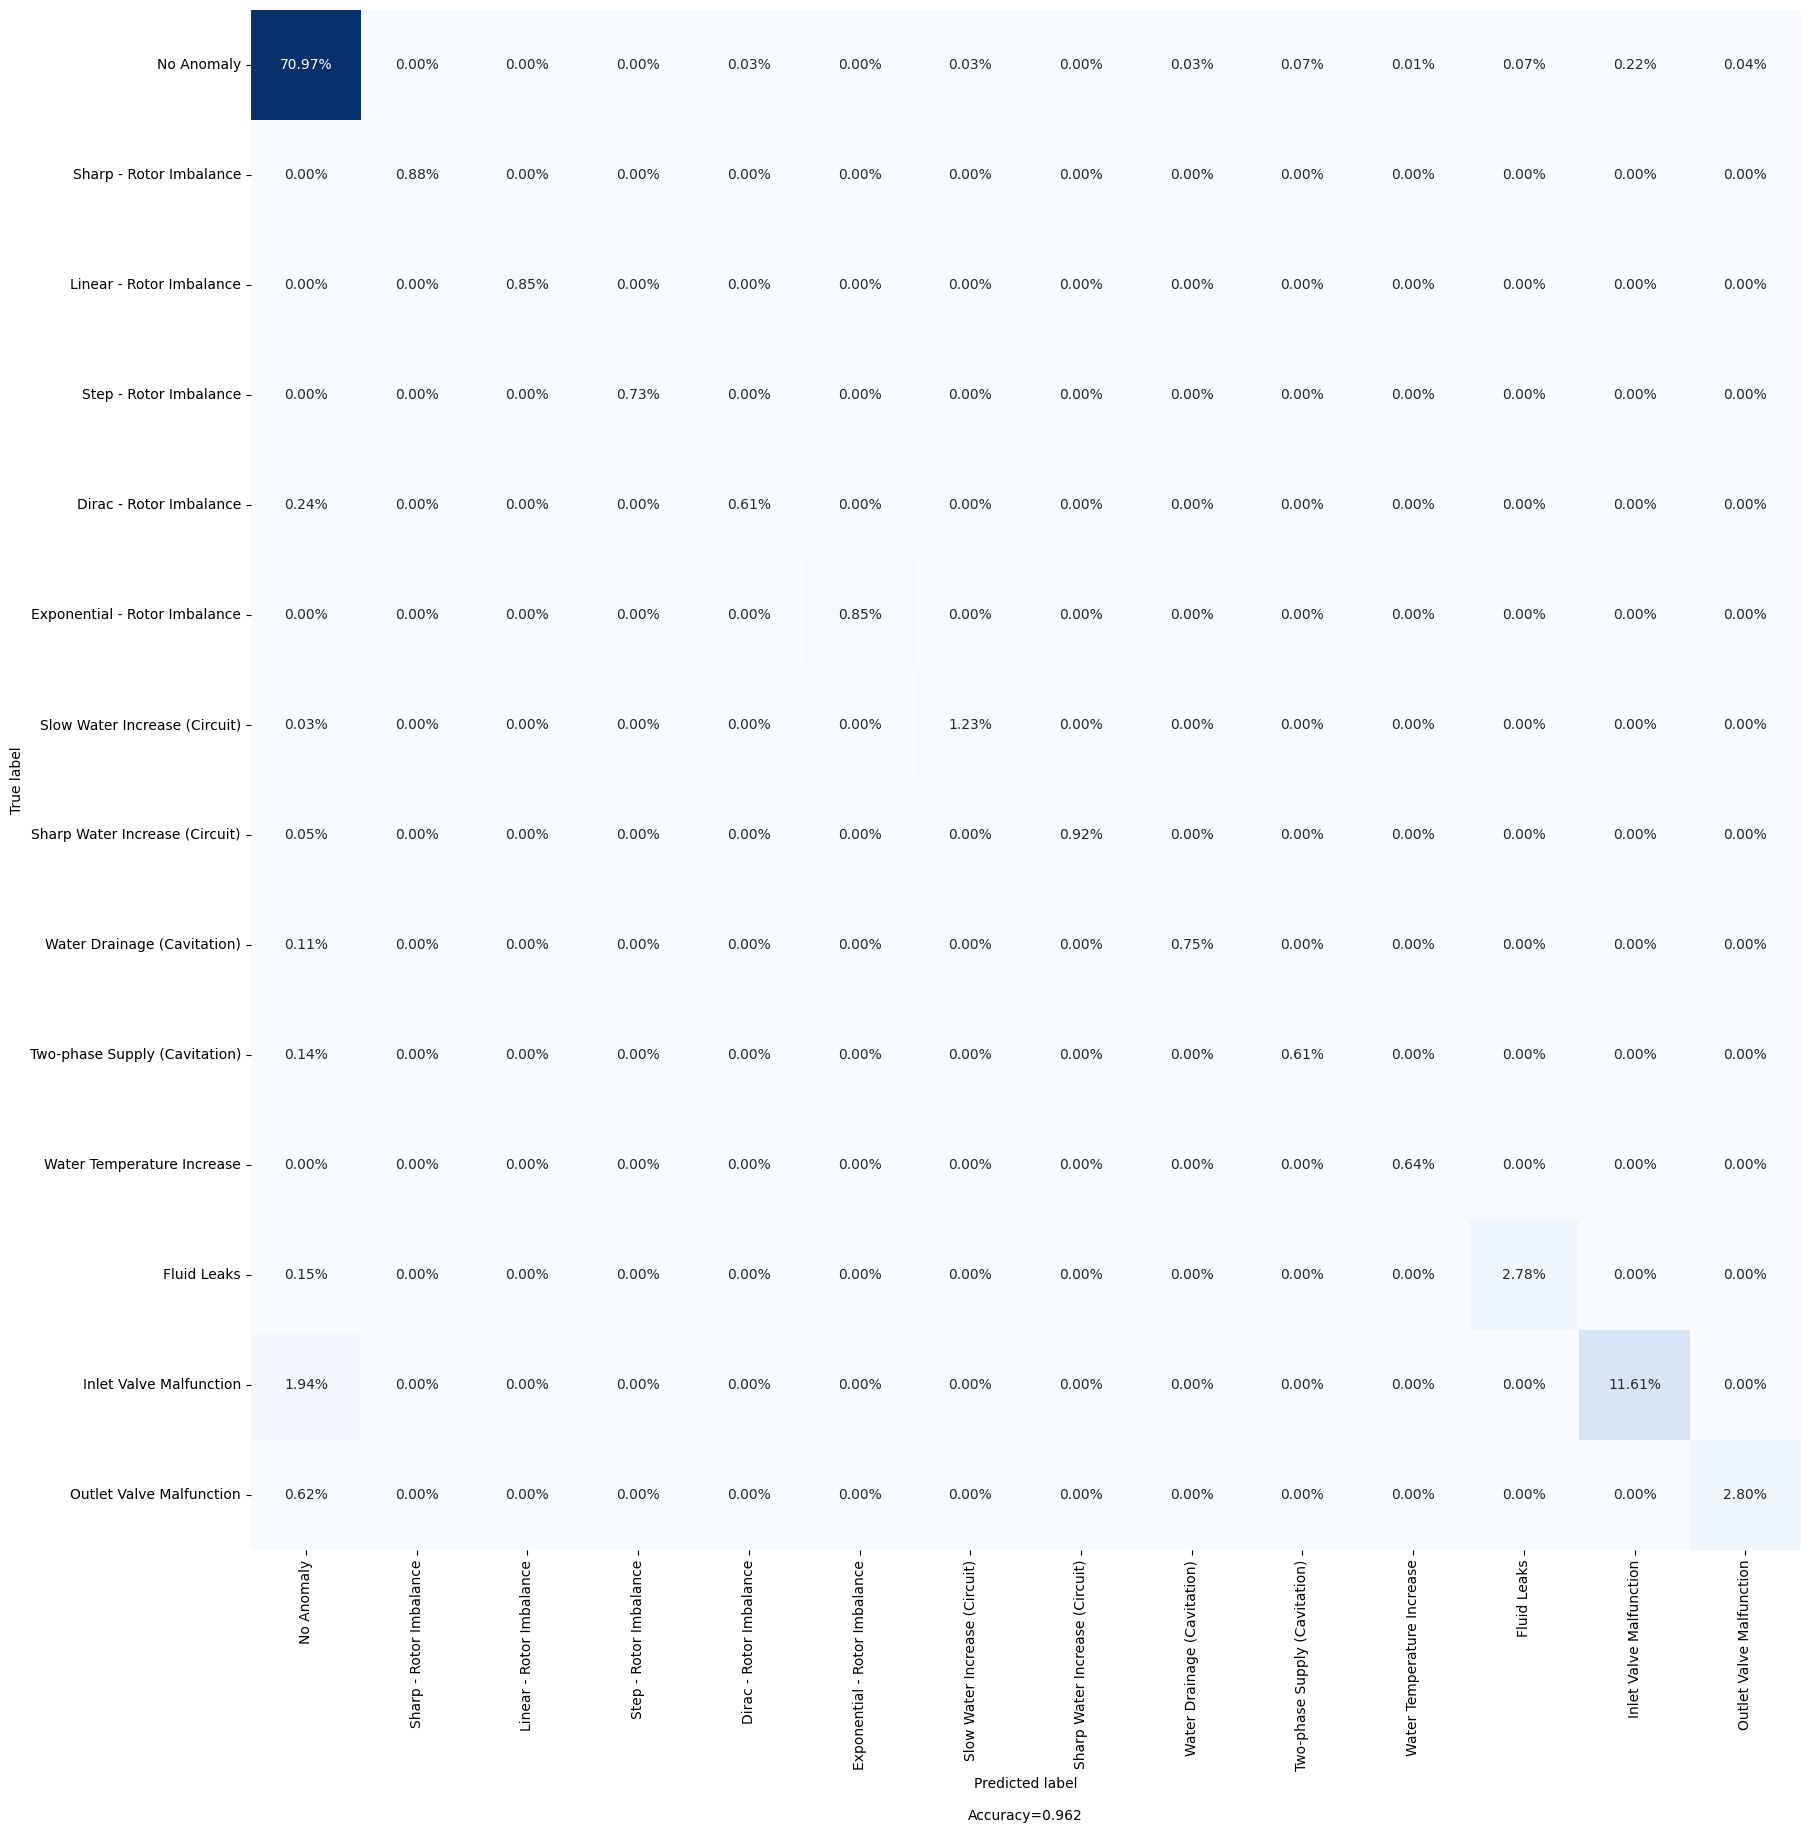

In [45]:
plot.make_confusion_matrix(
    confusion_matrix(y_test, y_pred),
    categories=anomaly_names,
    count=False,
    cbar=False,
    figsize=(20, 20)
)

### XGBoost

In [46]:
# 2. Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = XGBClassifier(objective='multi:softmax', num_class=len(anomaly_names), random_state=SEED)

model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.4f}")

Model Accuracy: 0.9702


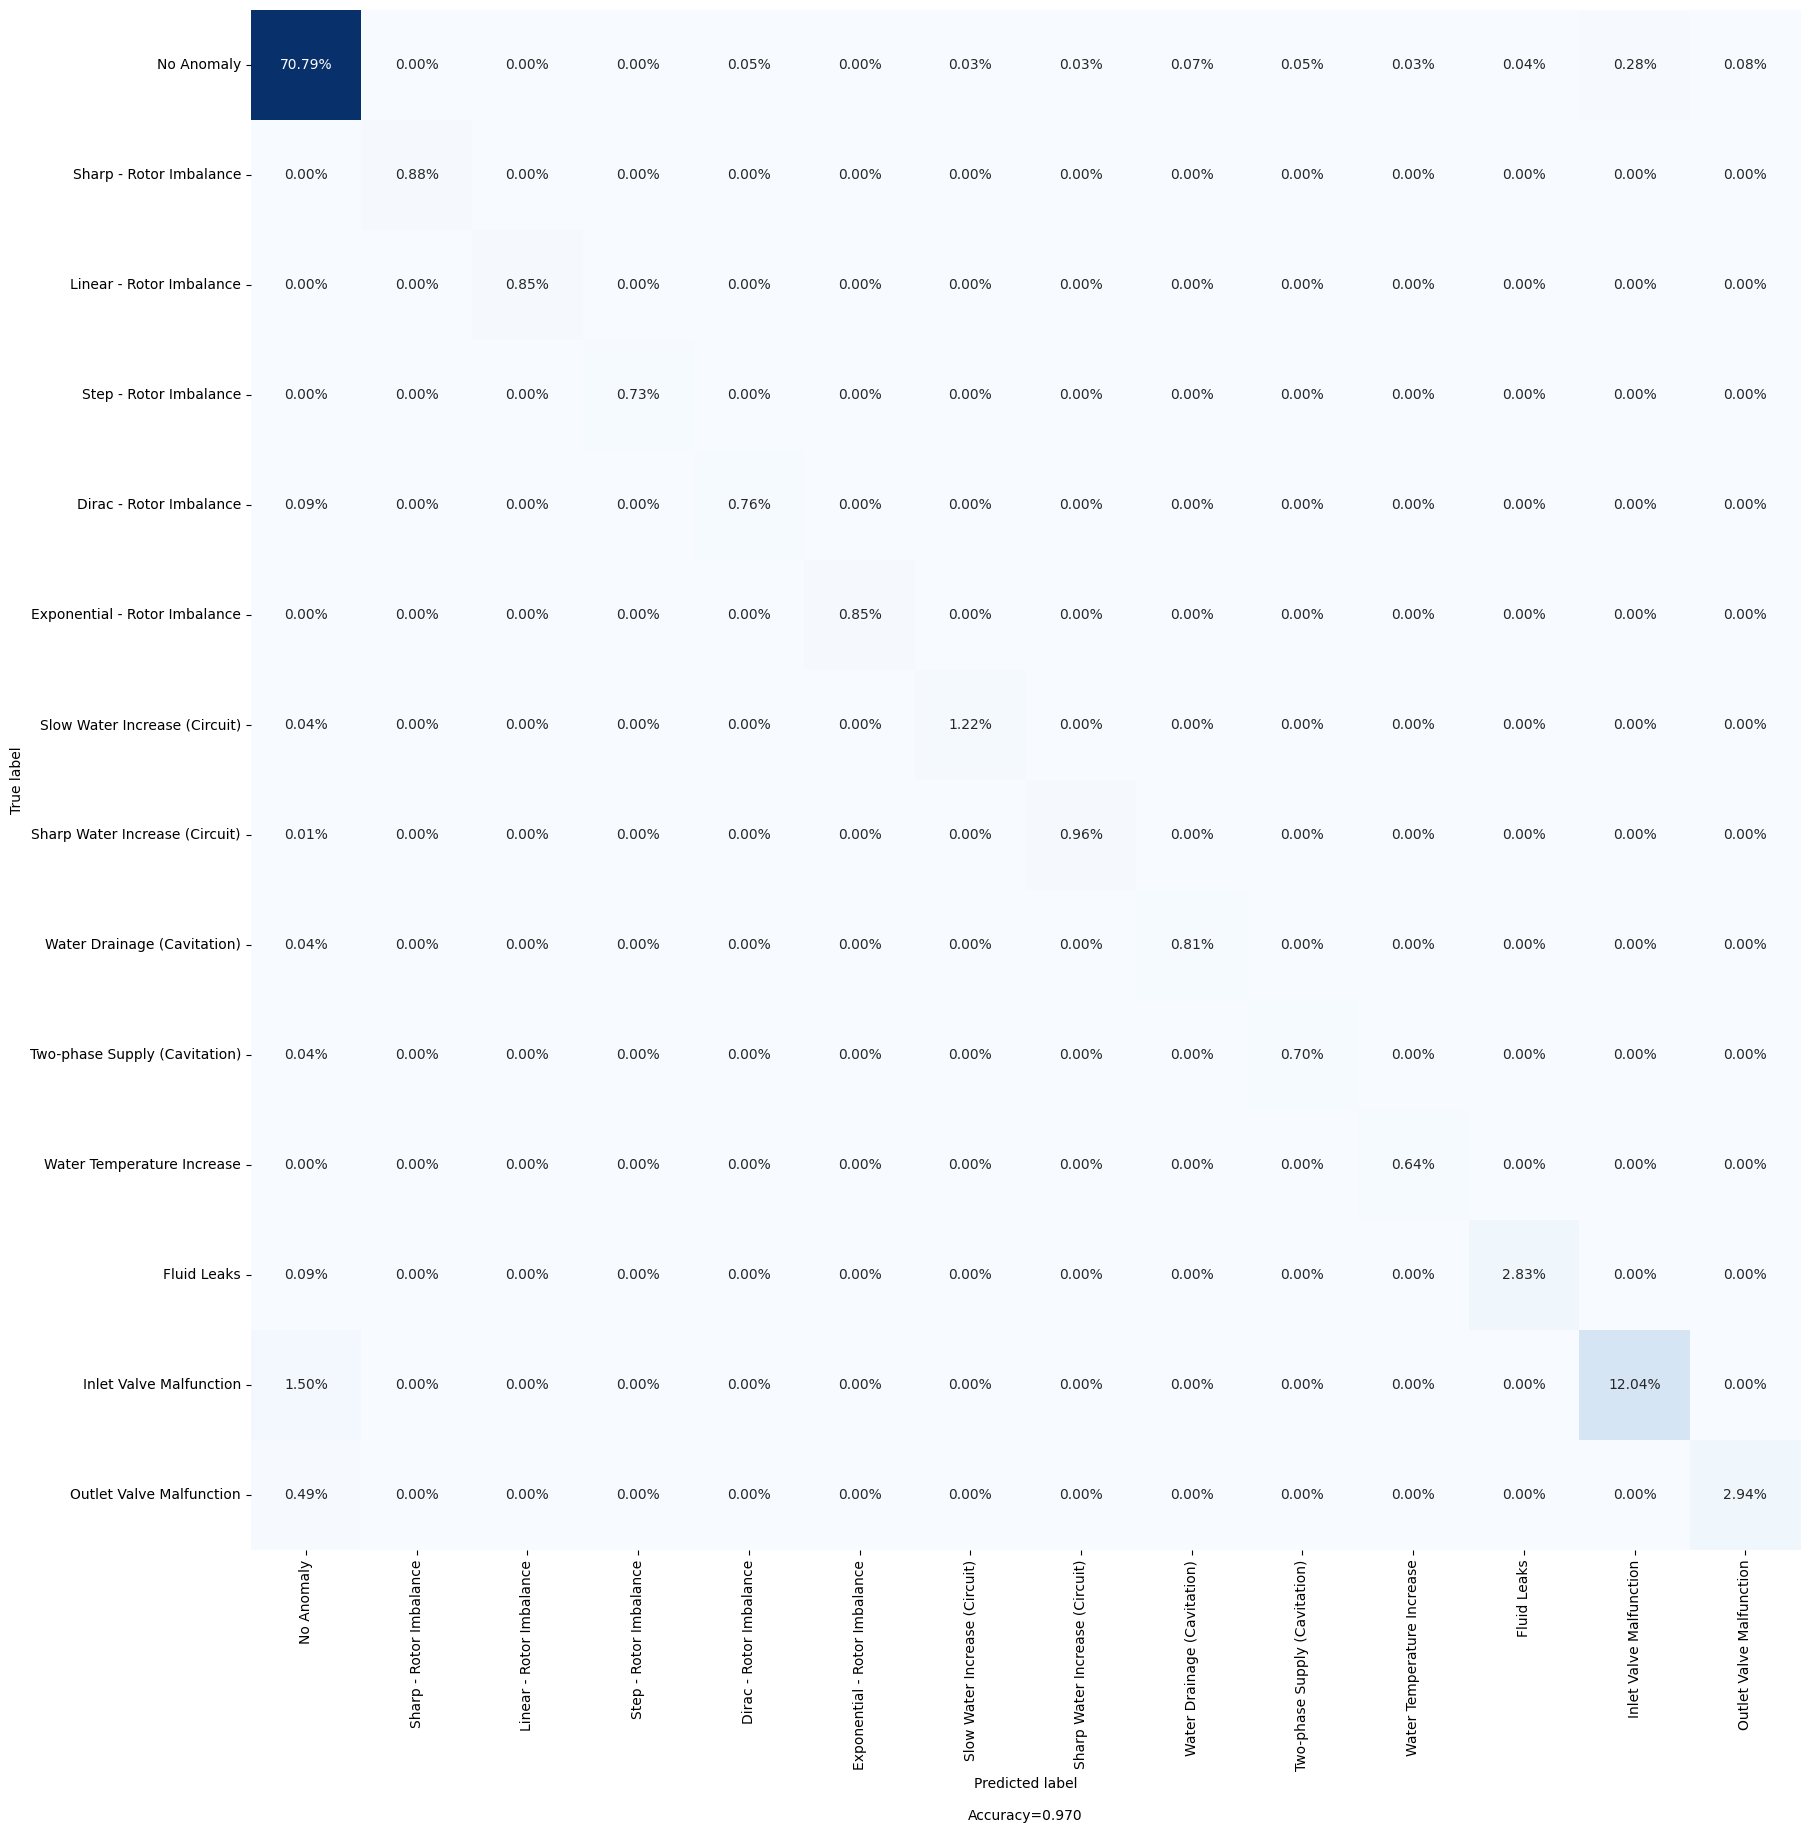

In [47]:
plot.make_confusion_matrix(
    confusion_matrix(y_test, y_pred),
    categories=anomaly_names,
    count=False,
    cbar=False,
    figsize=(20, 20)
)

In [ ]:
# # src/models.py (Updated with Supervised Multi-Class Classifiers)

# import pandas as pd
# import numpy as np
# from sklearn.covariance import MinCovDet
# from sklearn.svm import OneClassSVM
# from sklearn.neighbors import LocalOutlierFactor, NearestNeighbors
# from scipy.stats import chi2
# from sklearn.neighbors import KernelDensity
# from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
# from sklearn.metrics import pairwise_distances
# from collections import Counter
# from xgboost import XGBClassifier # Added XGBClassifier
# from sklearn.ensemble import IsolationForest, RandomForestClassifier # Added RandomForestClassifier


# # --- Helper for common anomaly score to label conversion (ONLY for unsupervised methods) ---
# # Keep this helper as it might be useful if you later decide to re-evaluate unsupervised methods
# # for binary anomaly detection, but it IS NOT RELEVANT for the multi-class classification task.
# def _convert_scores_to_labels(scores: np.ndarray, contamination: float, score_lower_is_anomaly: bool = False) -> tuple[np.ndarray, float]:
#     """
#     Converts anomaly scores to binary labels (1 for anomaly, 0 for normal).
#     Args:
#         scores (np.ndarray): Array of anomaly scores.
#         contamination (float): Estimated proportion of anomalies.
#         score_lower_is_anomaly (bool): If True, lower scores mean more anomalous.
#                                        If False (default), higher scores mean more anomalous.
#     Returns:
#         tuple: (labels, threshold)
#     """
#     if len(scores) == 0:
#         return np.array([], dtype=int), 0.0

#     if score_lower_is_anomaly:
#         threshold = np.percentile(scores, 100 * contamination)
#         labels = (scores < threshold).astype(int)
#     else:
#         threshold = np.percentile(scores, 100 * (1 - contamination))
#         labels = (scores > threshold).astype(int)
#     return labels, threshold

# # --- Existing unsupervised anomaly detection functions (Z-score, Modified Z-score, etc.) ---
# # (For brevity, I'm not pasting the code for Z-score, Modified Z-score, Multivariate Gaussian,
# # Isolation Forest, One-Class SVM, LOF, IQR, Percentile, KDE, kNN_distance, K-Means AD, DBSCAN AD,
# # and Hierarchical AD here. They would remain in this file as previously provided.
# # However, for multi-class anomaly *type* classification, these functions are NOT suitable
# # and should not be called in main.py for this specific goal.)


# # ----------------------------------------------------------------------------------------------------------------------
# # NEW SUPERVISED MULTI-CLASS CLASSIFICATION IMPLEMENTATIONS BELOW
# # These models are designed to classify 14 distinct classes (1 Normal + 13 Anomaly Types).
# # ----------------------------------------------------------------------------------------------------------------------

# # --- 11. Random Forest Classifier for Anomaly Type Classification ---
# def train_evaluate_random_forest_classifier(
#     X_train: pd.DataFrame,
#     y_train: pd.Series, # Now actively used for training
#     X_test: pd.DataFrame,
#     y_test: pd.Series, # Not used for training, but here for consistent signature (will be passed to evaluation)
#     n_estimators: int = 100,
#     max_depth: int = None,
#     class_weight_strategy: str = 'balanced', # Default to 'balanced' for imbalance
#     random_state: int = 42
# ) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
#     """
#     Trains and evaluates a Random Forest Classifier for multi-class anomaly type classification.
#     This model can distinguish between different anomaly types.

#     Args:
#         X_train (pd.DataFrame): Training feature set.
#         y_train (pd.Series): Training target labels (0 for Normal, 1-13 for Anomaly Types).
#         X_test (pd.DataFrame): Test feature set.
#         y_test (pd.Series): Test target labels (not used for model's internal prediction process,
#                               but for evaluation in main script).
#         n_estimators (int): The number of trees in the forest.
#         max_depth (int, optional): The maximum depth of the tree.
#         class_weight_strategy (str, optional): Strategy for handling class imbalance.
#                                               'balanced' automatically adjusts weights inversely
#                                               proportional to class frequencies.
#                                               'balanced_subsample' is similar but subsamples for each tree.
#                                               None for no weighting.
#         random_state (int): Random seed for reproducibility.

#     Returns:
#         tuple: (train_predicted_labels, train_predicted_probabilities,
#                 test_predicted_labels, test_predicted_probabilities)
#                Where 'probabilities' are for each of the 14 classes.
#     """
#     print(f"  Training Random Forest Classifier (Multi-Class) with n_estimators={n_estimators}, max_depth={max_depth}, class_weight='{class_weight_strategy}'...")

#     model = RandomForestClassifier(
#         n_estimators=n_estimators,
#         max_depth=max_depth,
#         class_weight=class_weight_strategy, # Pass the string directly for sklearn's internal handling
#         random_state=random_state,
#         n_jobs=-1 # Use all available cores
#     )
    
#     # Train the model using the provided X_train and y_train
#     model.fit(X_train, y_train)

#     # Predict labels and probabilities for the training set
#     train_predicted_labels = model.predict(X_train)
#     train_predicted_probabilities = model.predict_proba(X_train) # Probabilities for each of the 14 classes

#     # Predict labels and probabilities for the test set
#     test_predicted_labels = model.predict(X_test)
#     test_predicted_probabilities = model.predict_proba(X_test)

#     print(f"  Random Forest Classifier trained.")
#     return train_predicted_labels, train_predicted_probabilities, test_predicted_labels, test_predicted_probabilities


# # --- 12. XGBoost Classifier for Anomaly Type Classification ---
# def train_evaluate_xgboost_classifier(
#     X_train: pd.DataFrame,
#     y_train: pd.Series,
#     X_test: pd.DataFrame,
#     y_test: pd.Series,
#     n_estimators: int = 100,
#     learning_rate: float = 0.1,
#     max_depth: int = 3,
#     use_sample_weights: bool = True, # Flag to enable custom sample weighting for imbalance
#     random_state: int = 42
# ) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
#     """
#     Trains and evaluates an XGBoost Classifier for multi-class anomaly type classification.
#     This model can distinguish between different anomaly types.

#     Args:
#         X_train (pd.DataFrame): Training feature set.
#         y_train (pd.Series): Training target labels (0 for Normal, 1-13 for Anomaly Types).
#         X_test (pd.DataFrame): Test feature set.
#         y_test (pd.Series): Test target labels (not used for model's internal prediction process,
#                               but for evaluation in main script).
#         n_estimators (int): Number of boosting rounds.
#         learning_rate (float): Step size shrinkage to prevent overfitting.
#         max_depth (int): Maximum depth of a tree.
#         use_sample_weights (bool): If True, computes and uses sample weights to address class imbalance.
#                                    Weights are inversely proportional to class frequencies.
#         random_state (int): Random seed for reproducibility.

#     Returns:
#         tuple: (train_predicted_labels, train_predicted_probabilities,
#                 test_predicted_labels, test_predicted_probabilities)
#                Where 'probabilities' are for each of the 14 classes.
#     """
#     print(f"  Training XGBoost Classifier (Multi-Class) with n_estimators={n_estimators}, learning_rate={learning_rate}, max_depth={max_depth}, use_sample_weights={use_sample_weights}...")

#     sample_weights = None
#     if use_sample_weights:
#         print(f"    Calculating and applying sample weights for class imbalance.")
#         # Calculate sample weights based on inverse of class frequencies
#         # This gives higher weight to samples from rarer classes.
#         classes = np.unique(y_train)
#         class_counts = Counter(y_train)
#         total_samples = len(y_train)
        
#         # Compute inverse of class frequency, then apply to each sample
#         # A common formula: weight_for_class_i = total_samples / (num_classes * count_of_class_i)
#         # Or simpler: total_samples / count_of_class_i
#         # Let's use total_samples / count_of_class_i for more pronounced weighting.
#         weights_dict = {cls: total_samples / count for cls, count in class_counts.items()}
#         sample_weights = np.array([weights_dict[label] for label in y_train])

#     # For multi-class classification, `objective` should be 'multi:softprob' to get probabilities
#     # `num_class` must be explicitly set to the number of unique classes.
#     model = XGBClassifier(
#         n_estimators=n_estimators,
#         learning_rate=learning_rate,
#         max_depth=max_depth,
#         objective='multi:softprob', # To get probabilities for each class
#         num_class=len(np.unique(y_train)), # Number of unique classes in the target variable
#         use_label_encoder=False, # Suppress warning for future versions (should be default False soon)
#         eval_metric='mlogloss', # Evaluation metric for multi-class classification
#         random_state=random_state,
#         n_jobs=-1 # Use all available cores
#     )
    
#     # Train the model using sample weights if enabled
#     model.fit(X_train, y_train, sample_weight=sample_weights)

#     # Predict probabilities for train and test sets
#     train_predicted_probabilities = model.predict_proba(X_train)
#     test_predicted_probabilities = model.predict_proba(X_test)

#     # Convert probabilities to class labels by selecting the class with the highest probability
#     train_predicted_labels = np.argmax(train_predicted_probabilities, axis=1)
#     test_predicted_labels = np.argmax(test_predicted_probabilities, axis=1)

#     print(f"  XGBoost Classifier trained.")
#     return train_predicted_labels, train_predicted_probabilities, test_predicted_labels, test_predicted_probabilities